# 🧪 Uczenie Nadzorowane - SVM: Laboratorium

**Wymagania wstępne:** zapoznaj się z notebookiem demonstracyjnym przed przystąpieniem do zadań.

---

## 📌 Zasady

- Pracujesz na **własnym zbiorze danych** (zdyskretyzowanym, wybranym na pierwszych zajęciach)
- Klasyfikacja zawsze odbywa się na **wszystkich cechach** zbioru
- Używaj **`Pipeline(StandardScaler + SVC)`** - normalizacja musi być wewnątrz CV

---

## ⚙️ Import bibliotek i wczytanie danych

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, ShuffleSplit,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


In [5]:
# TODO: wczytaj własny zbiór danych
# df = pd.read_csv('...')
# FEATURES = [...]   # lista kolumn z cechami
# TARGET   = '...'   # nazwa kolumny decyzyjnej

# ──────────────────────────────────────────────────────────────────────
# ⚠️  WAŻNE: sprawdź typy kolumn PRZED podziałem na X i y
# print(df.dtypes)
# print(df.nunique())  # liczba unikalnych wartości w każdej kolumnie
#
# Jeśli masz kolumny kategoryczne (dtype=object lub category), NIE możesz
# ich bezpośrednio podać do StandardScaler ani SVC.
#
# Schemat postępowania:
#
#   from sklearn.compose import ColumnTransformer
#   from sklearn.preprocessing import OneHotEncoder, TargetEncoder  # TE: sklearn>=1.3
#
#   num_cols = [...]   # kolumny liczbowe
#   cat_cols = [...]   # kolumny kategoryczne nominalne
#
#   preprocessor = ColumnTransformer([
#       ('num', StandardScaler(),                       num_cols),
#       ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),  # mało kategorii
#       # ('cat', TargetEncoder(),                      cat_cols),  # dużo kategorii
#   ])
#
#   pipe = Pipeline([('prep', preprocessor), ('svm', SVC(...))])
#
# Więcej szczegółów: sekcja 4b notebooka demonstracyjnego.
# ──────────────────────────────────────────────────────────────────────

# X = df[FEATURES].values
# y = df[TARGET].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
# )

# print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
# print(f'Zbiór testowy:    {X_test.shape[0]} próbek')
# print(f'Klasy: {sorted(np.unique(y))}')

In [6]:
# TODO: wczytaj własny zbiór danych
df = pd.read_csv('data_discretized.csv')

FEATURES = ['STG', 'SCG', 'STR', 'LPR', 'PEG']   # lista kolumn z cechami
TARGET   = 'UNS'                                # nazwa kolumny decyzyjnej


print(df.dtypes)
print(df.nunique())  # liczba unikalnych wartości w każdej kolumnie

# Kolumny liczbowe i kategoryczne
num_cols = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
cat_cols = []

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                       num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

pipe = Pipeline([
    ('prep', preprocessor),
    ('svm', SVC())
])




X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
print(f'Zbiór testowy:    {X_test.shape[0]} próbek')
print(f'Klasy: {sorted(np.unique(y))}')

STG    float64
SCG    float64
STR    float64
LPR    float64
PEG    float64
UNS     object
dtype: object
STG    4
SCG    4
STR    4
LPR    4
PEG    4
UNS    4
dtype: int64
Zbiór treningowy: 282 próbek
Zbiór testowy:    121 próbek
Klasy: ['High', 'Low', 'Middle', 'Very Low']


---
# Zadanie 1 - Dobór optymalnych hiperparametrów (kernel, C, gamma)

Twoim celem jest znalezienie najlepszej kombinacji hiperparametrów SVM
przy użyciu MCCV jako metody walidacji.

**Wymagania:**

1. Przetestuj **wszystkie cztery kernele**: `linear`, `rbf`, `poly`, `sigmoid`
2. Użyj **MCCV** (ShuffleSplit, 30 iteracji, test=30%) jako metody walidacji
3. Użyj `Pipeline(StandardScaler + SVC)` - standaryzacja musi być wewnątrz CV
4. Dla każdego kernela przetestuj wartości `C` ∈ {0.01, 0.1, 1, 10, 100}
   - Dla `rbf` i `sigmoid` dodatkowo przetestuj `gamma` ∈ {0.001, 0.01, 0.1, 1}
   - Dla `poly` dodatkowo przetestuj `degree` ∈ {2, 3, 4}
5. Dla każdego kernela wypisz: najlepsze parametry, średnią accuracy i odchylenie standardowe
6. Narysuj wykres słupkowy porównujący najlepszy wynik dla każdego kernela

> 💡 Wskazówka: możesz użyć zagnieżdżonej pętli lub osobnych bloków dla każdego kernela.

In [7]:
cv_mccv = ShuffleSplit(
    n_splits=30,
    test_size=0.30,
    random_state=RANDOM_STATE
)

C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]
degree_values = [2, 3, 4]

results = []

for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:

    if kernel == 'linear':
        param_list = [{'kernel': kernel, 'C': C} for C in C_values]

    elif kernel in ['rbf', 'sigmoid']:
        param_list = [
            {'kernel': kernel, 'C': C, 'gamma': gamma}
            for C in C_values
            for gamma in gamma_values
        ]

    elif kernel == 'poly':
        param_list = [
            {'kernel': kernel, 'C': C, 'degree': degree}
            for C in C_values
            for degree in degree_values
        ]

    for params in param_list:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(**params))
        ])

        scores = cross_val_score(
            pipe,
            X,
            y,
            cv=cv_mccv,
            scoring='accuracy'
        )

        row = params.copy()
        row['mean_accuracy'] = scores.mean()
        row['std_accuracy'] = scores.std()
        results.append(row)

results_df = pd.DataFrame(results)

best_by_kernel = (
    results_df
    .sort_values('mean_accuracy', ascending=False)
    .groupby('kernel')
    .head(1)
    .sort_values('mean_accuracy', ascending=False)
)

best_by_kernel

,kernel,C,mean_accuracy,std_accuracy,gamma,degree
19,rbf,10.0,0.849587,0.033631,0.10,NaN
3,linear,10.0,0.822039,0.027718,NaN,NaN
57,sigmoid,100.0,0.816804,0.027992,0.01,NaN
35,poly,10.0,0.769146,0.044246,NaN,3.0


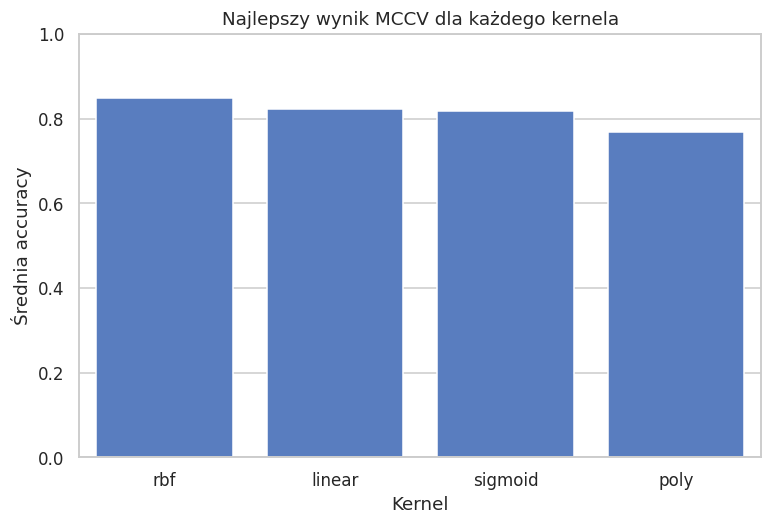

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=best_by_kernel,
    x='kernel',
    y='mean_accuracy'
)
plt.title("Najlepszy wynik MCCV dla każdego kernela")
plt.ylabel("Średnia accuracy")
plt.xlabel("Kernel")
plt.ylim(0, 1)
plt.show()

**Komentarz do Zadania 1** - odpowiedz na pytania:

1. Który kernel dał najlepsze wyniki na Twoim zbiorze? Czy wynik jest zaskakujący?
2. Jak duży wpływ na wyniki miał dobór *C*? Czy model jest wrażliwy na ten parametr?
3. Dla kerneli z parametrem *gamma*: jak zachowuje się model dla bardzo małych i bardzo dużych wartości?

1. Najlepszy wynik uzyskał kernel rbf z parametrami C=10 i gamma=0.1. Średnia accuracy wyniosła około 0.8496, a odchylenie standardowe około 0.0336. Wynik nie jest zaskakujący, ponieważ kernel RBF dobrze radzi sobie z nieliniowymi zależnościami między cechami.
2. Dobór parametru C miał wyraźny wpływ na wyniki. Dla zbyt małych wartości C model był zbyt prosty i słabiej dopasowany do danych. Większe wartości C, szczególnie C=10, poprawiły wynik, ale dalsze zwiększanie nie zawsze dawało lepszą jakość. Model jest więc wrażliwy na ten parametr.
3. Dla kerneli z parametrem gamma bardzo małe wartości dawały słabe wyniki, bo granica decyzyjna była zbyt gładka. Bardzo duże wartości gamma również nie były najlepsze, ponieważ model mógł nadmiernie dopasowywać się do danych. Najlepsze wyniki pojawiły się dla wartości pośrednich, szczególnie gamma=0.1

---
# Zadanie 2 - GridSearchCV i automatyczne przeszukiwanie hiperparametrów

Dla najlepszego kernela z Zadania 1 przeprowadź pełne przeszukiwanie siatki parametrów
z użyciem `GridSearchCV`.

**Wymagania:**

1. Wybierz kernel z najlepszym wynikiem z Zadania 1 - uzasadnij wybór
2. Zdefiniuj siatkę parametrów (`param_grid`) dla wybranego kernela:
   - `C` ∈ {0.01, 0.1, 1, 10, 100, 1000}
   - `gamma` ∈ {0.0001, 0.001, 0.01, 0.1, 1} *(jeśli dotyczy kernela)*
   - `degree` ∈ {2, 3, 4, 5} *(tylko dla `poly`)*
3. Użyj `GridSearchCV` z `StratifiedKFold(n_splits=5)` jako CV wewnętrznym, w `Pipeline`
4. Wypisz: najlepsze parametry i najlepszą CV accuracy
5. Narysuj **heatmapę** wyników (C × gamma lub C × degree)

> 💡 Wskazówka: pamiętaj o prefiksie `svm__` dla parametrów w `param_grid`  
> (np. `'svm__C': [...]`, `'svm__gamma': [...]`).

In [9]:
best_kernel = 'rbf'

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel=best_kernel))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100, 1000],
    'svm__gamma': [0.0001, 0.001, 0.01, 0.1, 1]
}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)

print("Najlepsze parametry:")
print(grid.best_params_)

print("\nNajlepsza accuracy CV:")
print(grid.best_score_)

Najlepsze parametry:
{'svm__C': 10, 'svm__gamma': 0.1}

Najlepsza accuracy CV:
0.8560493827160494


Parametr degree nie został uwzględniony w GridSearchCV,
ponieważ dotyczy tylko kernela poly, który nie był najlepszy
w Zadaniu 1.

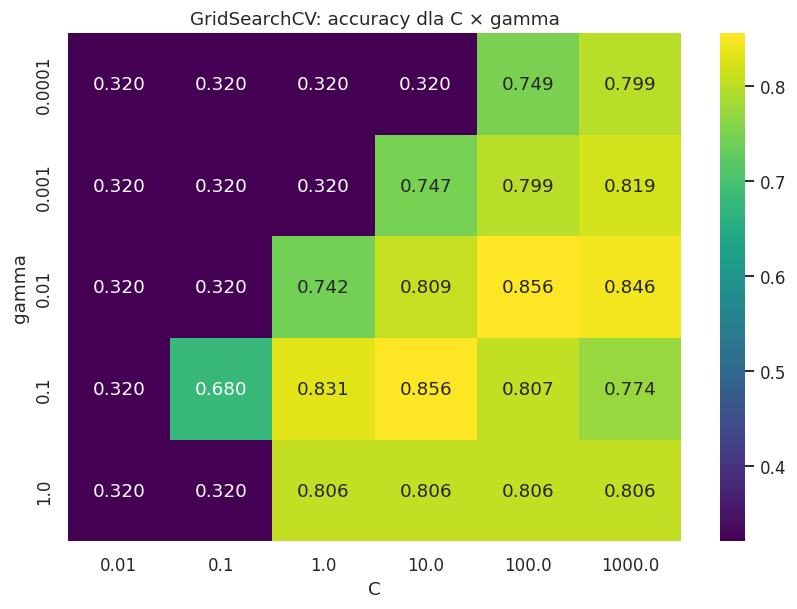

In [10]:
grid_results = pd.DataFrame(grid.cv_results_)

heatmap_data = grid_results.pivot_table(
    values='mean_test_score',
    index='param_svm__gamma',
    columns='param_svm__C'
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)
plt.title("GridSearchCV: accuracy dla C × gamma")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

**Komentarz do Zadania 2** - odpowiedz na pytania:

1. Czy wyniki GridSearchCV pokrywają się z ręcznym przeszukiwaniem z Zadania 1?
2. Co widać na heatmapie - które kombinacje parametrów dają najlepsze / najgorsze wyniki?
3. Czy siatka parametrów była wystarczająco gęsta? Gdzie warto by ją zagęścić?

1. Wyniki GridSearchCV pokrywają się z ręcznym przeszukiwaniem z Zadania 1. W obu przypadkach najlepszy był kernel rbf, a najlepsze parametry to C=10 oraz gamma=0.1
2. Na heatmapie najlepsze wyniki występują dla kombinacji około C=10 i gamma=0.1 oraz dla C=100, gamma=0.01. Najgorsze wyniki są widoczne dla bardzo małych wartości C, gdzie accuracy wynosi około 0.320, co oznacza, że model praktycznie nie uczy się dobrze rozróżniać klas.
3. iatka parametrów była wystarczająca do znalezienia dobrego obszaru parametrów. Warto byłoby ją zagęścić w okolicy najlepszych wyników, np. dla C między 5–50 oraz gamma między 0.03–0.3, żeby dokładniej sprawdzić maksimum.

---
# Zadanie 3 - Klasyfikacja finalnym modelem i ocena wyników

Na podstawie wyników z Zadań 1 i 2 wybierz najlepszą kombinację hiperparametrów
i przeprowadź pełną ocenę finalnego modelu.

**Wymagania:**

1. Wybierz najlepszy kernel i parametry z poprzednich zadań - uzasadnij wybór
2. Zastosuj **Stratified K-Fold Cross-Validation** (5 foldów) i wypisz wyniki per fold oraz średnią
3. Wytrenuj finalny model na zbiorze treningowym (podział 70/30, stratyfikacja), oceń na testowym
4. Wyświetl **macierz pomyłek** i **raport klasyfikacji** (`classification_report`)
5. Porównaj wyniki dla `kernel='linear'` vs najlepszego kernela - który jest lepszy i dlaczego?

> 💡 Wskazówka: do K-Fold używaj `Pipeline` tak samo jak w poprzednich zadaniach.

In [11]:
best_params = grid.best_params_

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=best_params['svm__C'],
        gamma=best_params['svm__gamma']
    ))
])

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    final_model,
    X_train,
    y_train,
    cv=cv_final,
    scoring='accuracy'
)

print("Wyniki Stratified K-Fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nŚrednia CV: {cv_scores.mean():.4f}")
print(f"Odchylenie standardowe CV: {cv_scores.std():.4f}")

Wyniki Stratified K-Fold:
Fold 1: 0.8421
Fold 2: 0.8070
Fold 3: 0.8393
Fold 4: 0.8571
Fold 5: 0.8214

Średnia CV: 0.8334
Odchylenie standardowe CV: 0.0174


In [12]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy na zbiorze testowym: {test_accuracy:.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Accuracy na zbiorze testowym: 0.8595

Raport klasyfikacji:
              precision    recall  f1-score   support

        High       0.88      0.93      0.90        30
         Low       0.89      0.82      0.85        39
      Middle       0.86      0.84      0.85        37
    Very Low       0.76      0.87      0.81        15

    accuracy                           0.86       121
   macro avg       0.85      0.86      0.85       121
weighted avg       0.86      0.86      0.86       121



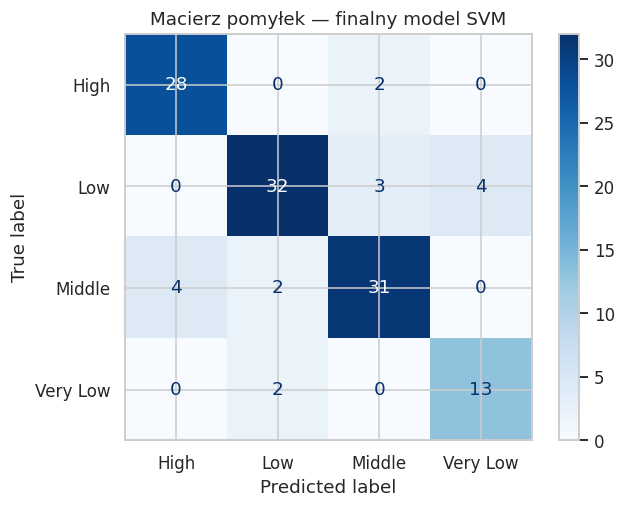

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(cmap="Blues")
plt.title("Macierz pomyłek — finalny model SVM")
plt.show()

In [14]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=10))
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print("Accuracy linear:")
print(accuracy_score(y_test, y_pred_linear))

print("\nAccuracy najlepszy model rbf:")
print(test_accuracy)

Accuracy linear:
0.8512396694214877

Accuracy najlepszy model rbf:
0.859504132231405


**Komentarz do Zadania 3** - odpowiedz na pytania:

1. Które klasy są najczęściej mylone? Co może być tego przyczyną?
2. Jak wyniki Stratified K-Fold CV mają się do wyników na zbiorze testowym?
   Czy widać oznaki overfittingu lub underfittingu?
3. Porównaj SVM z kNN (z poprzednich zajęć): który algorytm działa lepiej na Twoich danych?
   Jakie cechy zbioru mogą to tłumaczyć?

1. Najczęściej mylone klasy to Low z Middle oraz Low z Very Low. Widać też pomyłki między Middle i High. Przyczyną może być podobieństwo poziomów wiedzy w sąsiednich klasach — wartości cech dla tych klas mogą częściowo się nakładać.
2. Wynik Stratified K-Fold CV wyniósł średnio około 0.8334, a wynik na zbiorze testowym około 0.8595. Są to wartości dość zbliżone, więc nie widać silnego overfittingu ani underfittingu. Model generalizuje poprawnie.
3. Najlepszy SVM z kernelem rbf uzyskał accuracy około 0.8595, a SVM liniowy około 0.8512. RBF jest minimalnie lepszy, ponieważ potrafi uchwycić nieliniowe zależności w danych. Różnica nie jest jednak bardzo duża, więc dane są częściowo możliwe do rozdzielenia także modelem liniowym.